# 구간별 여론 분석 파이프라인

**연구 대상:** 네이버 블로그·카페의 `의대 증원` 관련 게시글 8,972건  
**분석 구간:** 2024년 1월부터 2025년 6월까지 4개 section  
**입력:** `data/integrated/crolling_total_estate_press.pkl`  
**출력:** `data/integrated/crolling_total_estate_press_layered.pkl`, `outputs/pipeline/` 하위 CSV·PNG  

이 노트북은 전처리된 통합 데이터를 읽어 공통·구간별 불용어를 적용하고, 워드클라우드·TF-IDF·K-Means·LDA·반응 지표·경량 감성 지표를 같은 실행 흐름에서 확인하기 위한 메인 분석 파일입니다.


**분석 목적**  
불용어 처리, 워드클라우드, TF-IDF, K-Means, LDA, 반응 지표, 경량 감성 지표를 한 노트북에서 재현한다.

**입력 데이터**  
`data/integrated/crolling_total_estate_press.pkl`

**주요 산출물**  
`outputs/pipeline/tfidf/`, `wordcloud/`, `kmeans/`, `lda/`, `sentiment/` 및 layered PKL


## 분석 단계 요약

| 단계 | 분석 목적 | 주요 결과 |
| --- | --- | --- |
| Step 0 | 통합 PKL을 불러오고 section·채널·명사 컬럼을 검증 | 문서 수, 구간별 분포, 채널 분포 |
| Step 1 | 공통 불용어를 적용해 전체 분석에서 반복되는 일반어를 제거 | `*_clean` 명사 컬럼 |
| Step 2 | 구간별 TF-IDF와 고착어 후보를 산출 | `tfidf/` CSV, 구간별 핵심어 후보 |
| Step 3 | 구간별 로컬 불용어를 반영해 최종 명사 리스트를 구성 | `nouns_final`, `corpus_final` |
| Step 4 | 빈도표·워드클라우드·TF-IDF 히트맵으로 시각적 경향 확인 | `wordcloud/`, `tfidf_heatmap_union_top.png` |
| Step 5 | 이후 분석 재현을 위해 layered PKL 저장 | `crolling_total_estate_press_layered.pkl` |
| Step 6 | 전체 문서를 기준으로 K-Means와 LDA를 학습한 뒤 구간별 비율 계산 | `kmeans/`, `lda/` CSV·PNG |
| Step 7 | 군집·토픽 해석과 좋아요·댓글 반응 지표 비교 | 박스플롯, 보조 히트맵 |
| Step 8 | 사전 기반 경량 감성 점수로 구간별 정서 흐름 참고 | `sentiment/` CSV·PNG |

각 단계의 결과를 확인한 뒤 아래 해석 작성란에 수치와 그림을 근거로 직접 정리합니다.


```bash
pip install -r ../../requirements_pipeline.txt
```


In [1]:
# =============================================================================
# 경로·라이브러리 로드
# =============================================================================
# [실행 시 나오는 것] 보통 출력 없음. 에러가 나면 project_paths.py 위치나 폴더 구조를 확인하세요.
#
# [의미] PKL·불용어·CSV 저장 위치를 한곳에서 맞춥니다.
#   - PKL_IN / PKL_OUT : 통합 데이터 (blog+카페 등)
#   - STOP_COMMON + STOP_KO : 글로벌 불용어 두 파일을 합쳐 Step 1에 사용
#   - OUT_DIR : TF-IDF·CSV 등 → outputs/pipeline/tfidf/
#   - OUT_WC : 워드클라우드 PNG → outputs/pipeline/wordcloud/
# =============================================================================

import sys
from pathlib import Path

# 프로젝트 루트: notebooks/ 하위 어느 깊이에서 실행해도 동작
_cwd = Path.cwd().resolve()
for _d in [_cwd, *_cwd.parents]:
    if (_d / "notebooks" / "lib" / "notebook_bootstrap.py").is_file():
        sys.path.insert(0, str(_d / "notebooks" / "lib"))
        break
else:
    raise FileNotFoundError("notebooks/lib/notebook_bootstrap.py 을 찾을 수 없습니다. cwd=" + str(_cwd))

from notebook_bootstrap import setup_paths

PROJECT_ROOT = setup_paths()
sys.modules.pop("stopword_utils", None)
from project_paths import (
    DATA_INTEGRATED,
    CONFIG_STOPWORDS,
    OUTPUTS_PIPELINE_TFIDF,
    OUTPUTS_PIPELINE_WORDCLOUD,
    OUTPUTS_PIPELINE_KMEANS,
    OUTPUTS_PIPELINE_LDA,
)
from stopword_utils import (
    load_stopword_files,
    ensure_token_list,
    snapshot_noun_columns,
    apply_global_clean,
    row_merged_tokens,
    parse_comment_list_cell,
    safe_int_comment_cnt,
    apply_local_clean,
    section_mean_tfidf_matrix,
    unique_keyword_scores,
    document_frequency_from_texts,
    sticky_candidates_per_section,
)
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

OUT_DIR = OUTPUTS_PIPELINE_TFIDF
OUT_WC = OUTPUTS_PIPELINE_WORDCLOUD
for _p in (OUT_DIR, OUT_WC, OUTPUTS_PIPELINE_KMEANS, OUTPUTS_PIPELINE_LDA):
    _p.mkdir(parents=True, exist_ok=True)

PKL_IN = DATA_INTEGRATED / "crolling_total_estate_press.pkl"
PKL_OUT = DATA_INTEGRATED / "crolling_total_estate_press_layered.pkl"
STOP_COMMON = CONFIG_STOPWORDS / "stopwords_common.txt"
STOP_KO = CONFIG_STOPWORDS / "stopwords-ko.txt"


## Step 0 — 로드 및 검증


In [3]:
# =============================================================================
# 통합 PKL 로드 + 명사 컬럼 형식 통일
# =============================================================================
# [실행 시 나오는 것]
#   - shape (행수, 열수) : 전체 게시글(문서) 개수와 원본 컬럼 수
#   - columns 리스트 : title, doc, section, 명사 3종 등 원본 스키마
#   - section 값 카운트 : 분기(1~4)별 문서 수 — 어느 분기에 글이 많은지
#   - ch 값 카운트 : blog / cafe 등 채널 비중 (1구간 등 이상치는 다음 마크다운 아래 셀에서 cafe로 고쳐 PKL 저장)
#   - non-list after ensure: 0 이면 명사 컬럼이 모두 리스트로 잘 읽힌 것
# =============================================================================

with open(PKL_IN, "rb") as f:
    df = pickle.load(f)

for c in ["title_token_noun", "document_token_noun", "comment_token_noun"]:
    df[c] = df[c].map(ensure_token_list)

assert isinstance(df, pd.DataFrame), type(df)
print("shape", df.shape)
print(df.columns.tolist())
print(df["section"].value_counts().sort_index())
print(df["ch"].value_counts().head())

for c in ["title_token_noun", "document_token_noun", "comment_token_noun"]:
    bad = (~df[c].map(lambda x: isinstance(ensure_token_list(x), list))).sum()
    print(c, "non-list after ensure:", bad)


shape (8972, 11)
['title', 'doc', 'like', 'comment_cnt', 'comment_list', 'ch', 'date', 'section', 'title_token_noun', 'document_token_noun', 'comment_token_noun']
section
1    2303
2    2419
3    3017
4    1233
Name: count, dtype: int64
ch
blog    5234
cafe    3738
Name: count, dtype: int64
title_token_noun non-list after ensure: 0
document_token_noun non-list after ensure: 0
comment_token_noun non-list after ensure: 0


- 시계열 분포: 3구간(3,017건)에서 데이터가 가장 집중되어 있고, 4구간(1,233건)에서 급감하는 양상을 보임
- 해석: 의대 증원 논란이 3구간 시기에 가장 뜨거운 감자였거나, 담론의 정점을 찍었음을 시사.
- 채널 비중: 블로그(5,234건)가 카페(3,712건)보다 약 1.4배 많음


### Raw 스냅샷 (`*_raw`) 및 보조 컬럼


In [4]:
# =============================================================================
# Raw 스냅샷 + 댓글 메타 보조 컬럼
# =============================================================================
# [실행 시 나오는 것]
#   - title/document/comment_token_noun_raw 에 대한 describe():
#       count = 문서(행) 수, mean = 글 한 편당 명사 개수 평균, min/max = 짧은/긴 글 극단값
#       → “본문 명사가 평균 몇 개인지” 대략적 규모 감을 잡을 수 있음
# [DataFrame에 추가되는 열]
#   - *_raw : 이후 불용어 제거와 비교할 “원본 명사” 백업
#   - comment_list_parsed : 댓글 목록을 dict 리스트로 파싱한 것(분석에 쓰려면)
#   - comment_cnt_int : 댓글 수를 숫자로 통일
# =============================================================================

snapshot_noun_columns(df)

df["comment_list_parsed"] = df["comment_list"].map(parse_comment_list_cell)
df["comment_cnt_int"] = df["comment_cnt"].map(safe_int_comment_cnt)

for c in ["title_token_noun_raw", "document_token_noun_raw", "comment_token_noun_raw"]:
    print(c, df[c].map(len).describe())


title_token_noun_raw count    8972.000000
mean        6.278199
std         4.133051
min         0.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        31.000000
Name: title_token_noun_raw, dtype: float64
document_token_noun_raw count    8972.000000
mean      307.304837
std       481.142333
min         0.000000
25%        61.750000
50%       183.000000
75%       360.000000
max      5382.000000
Name: document_token_noun_raw, dtype: float64
comment_token_noun_raw count    8972.000000
mean       77.594851
std       174.860200
min         0.000000
25%         6.000000
50%        19.000000
75%        68.000000
max      3229.000000
Name: comment_token_noun_raw, dtype: float64


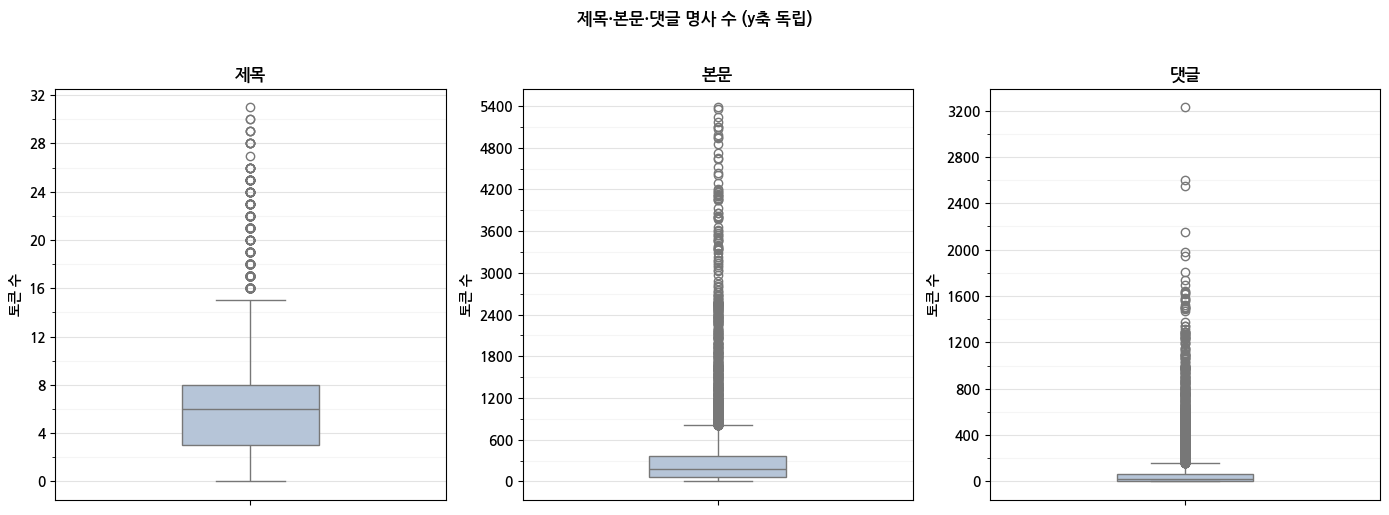

In [5]:
# =============================================================================
# Raw 스냅샷 직후: 제목·본문·댓글 명사 개수(행별 리스트 길이) boxplot
# =============================================================================
# 한글: 프로젝트 루트 아래 nanum-gothic/NanumGothicBold.ttf (구 file_path + 'nanum-gothic/...')
# =============================================================================

from matplotlib import font_manager

_nanum_ttf = PROJECT_ROOT / "nanum-gothic" / "NanumGothicBold.ttf"
if not _nanum_ttf.is_file():
    raise FileNotFoundError(
        f"나눔고딕 폰트가 없습니다: {_nanum_ttf}\n"
        "프로젝트 루트에 nanum-gothic/NanumGothicBold.ttf 를 두세요."
    )
font_manager.fontManager.addfont(str(_nanum_ttf))
_nanum_name = font_manager.FontProperties(fname=str(_nanum_ttf)).get_name()
plt.rcParams["font.family"] = [_nanum_name]
plt.rcParams["axes.unicode_minus"] = False

plot_df = pd.DataFrame(
    {
        "제목": df["title_token_noun_raw"].map(len),
        "본문": df["document_token_noun_raw"].map(len),
        "댓글": df["comment_token_noun_raw"].map(len),
    }
)

# 한 figure에 3개 박스 — y축 범위를 각각 독립(본문 이상치가 제목·댓글 축을 눌러서 박스가 안 보이는 문제 방지)
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols = ["제목", "본문", "댓글"]
for ax, col in zip(axes, cols):
    sns.boxplot(y=plot_df[col], ax=ax, width=0.35, color="lightsteelblue")
    ax.set_title(col)
    ax.set_ylabel("토큰 수")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelbottom=False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10, min_n_ticks=8))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which="major", axis="y", alpha=0.35)
    ax.grid(True, which="minor", axis="y", alpha=0.12)

fig.suptitle("제목·본문·댓글 명사 수 (y축 독립)", y=1.02)
plt.tight_layout()
plt.show()


1. 데이터 규모 및 정보량 해석
- 제목 (title_token_noun_raw): 평균 약 6개의 명사가 추출
해석: 제목은 압축된 정보를 담고 있으므로, 제목 분석만으로도 핵심 이슈(의대 증원, 파업 등)를 파악하기에 충분한 정보량. 최대 31개인 경우 제목이 매우 긴 뉴스 기사일 가능성이 높다.

- 본문 (document_token_noun_raw): 평균 307개, 최대 5,382개의 명사 추출
해석: 텍스트 데이터로서 풍부한 정보를 담고있음. 다만, 표준편차(std)가 481로 평균보다 크다는 것은 글의 길이가 매우 짧은 게시글부터 아주 긴 논평형 글까지 편차가 극심함을 의미.

- 댓글 (comment_token_noun_raw): 평균 77개의 명사 추출
해석: 본문 대비 약 1/4 수준의 정보량입니다. 댓글은 대중의 직접적인 감정이 드러나는 곳.

2. 데이터 특이사항 점검
min 값이 모두 0인 데이터들이 존재합니다.
해석: 명사가 하나도 추출되지 않은 행들입니다. 사진만 있는 게시글이거나 광고성 글일 수 있습니다.

## Step 1 — Global cleaning (`*_clean`)


In [7]:
# =============================================================================
# 글로벌 불용어 적용 → *_clean, corpus_clean
# =============================================================================
# [실행 시 나오는 것]
#   - merged stopword count : common + ko 에서 읽어 합친 불용어 개수 (많을수록 제거 후 토큰이 줄어듦)
#   - corpus_clean 토큰 개수 describe() : 글 한 편당 “정제 후” 남은 명사 토큰 수 분포
#       raw 대비 mean이 줄었으면 불용어가 잘 먹은 것
# [DataFrame에 추가되는 열]
#   - title/document/comment_token_noun_clean
#   - corpus_clean : 한 행 = 한 문서, 제목+본문+댓글 명사를 공백으로 이은 문자열 (TF-IDF 입력)
# =============================================================================

global_sw = load_stopword_files(STOP_COMMON, STOP_KO)
print("merged stopword count:", len(global_sw))

apply_global_clean(df, global_sw, src_suffix="_raw", dst_suffix="_clean")

df["corpus_clean"] = df.apply(lambda r: row_merged_tokens(r, suffix="_clean"), axis=1)
print(df["corpus_clean"].str.split().map(len).describe())


merged stopword count: 789
count    8972.000000
mean      324.531431
std       439.034467
min         0.000000
25%       106.000000
50%       206.500000
75%       368.000000
max      4843.000000
Name: corpus_clean, dtype: float64


- merged stopword count: 733
    - 해석: 범용적인 한국어 불용어와 직접 정의한 도메인 특화 불용어를 합쳐 총 733개의 금칙어 목록 생성

- corpus_clean 통계값 (Mean: 347.99):
    - 해석: 이전 단계의 본문 명사 평균이 307개였는데, 제목과 댓글 명사까지 합쳐진 corpus_clean의 평균이 347개로 나타났습니다.
    - 진단: 불용어 733개를 거쳤음에도 불구하고 한 문서당 약 348개의 유의미한 명사 토큰이 남았다는 것은, 분석에 방해되는 소음은 제거되면서도 핵심 정보량은 여전히 충분히 유지되고 있다는 아주 긍정적인 신호입니다. TF-IDF나 토픽 모델링을 돌리기에 최적의 상태입니다.


## Step 2 — 섹션별 TF-IDF


In [8]:
# =============================================================================
# TF-IDF 행렬 + 섹션별 평균 점수 표 (wide)
# =============================================================================
# [실행 시 나오는 것]
#   - wide shape (용어 수, 4) : 어휘(행) × 섹션 1~4 평균 TF-IDF
#   - 미리보기 표 : 섹션별 평균 TF-IDF 중 **최댓값** 기준 내림차순 상위 15행. 인덱스=단어, 열=분기별 평균 TF-IDF
#       값이 클수록 “그 분기 문서 전체”에서 그 단어가 상대적으로 중요
# [저장 파일] outputs/pipeline/tfidf_section_mean_wide.csv
#       → 엑셀로 열어 특정 단어를 검색하거나 정렬해 비교하기 좋음
# =============================================================================

texts = df["corpus_clean"].tolist()
sections = df["section"].to_numpy()

wide_tfidf, vec, X = section_mean_tfidf_matrix(
    texts, sections, section_ids=(1, 2, 3, 4), min_df=2, max_df=0.98
)
print("wide shape", wide_tfidf.shape)

# CSV·표: 4개 섹션 중 **최대 평균 TF-IDF** 기준 내림차순(어느 분기에서든 두드러진 단어가 위로)
_wide_sorted = (
    wide_tfidf.assign(_peak=wide_tfidf.max(axis=1))
    .sort_values("_peak", ascending=False)
    .drop(columns="_peak")
)
_wide_sorted.to_csv(OUT_DIR / "tfidf_section_mean_wide.csv", encoding="utf-8-sig")

_wide_sorted.head(15)


wide shape (32608, 4)


,section_1_mean_tfidf,section_2_mean_tfidf,section_3_mean_tfidf,section_4_mean_tfidf
정부,0.054792,0.039439,0.027843,0.022009
정원,0.052050,0.028631,0.019245,0.027417
지역,0.038890,0.027887,0.020424,0.023262
수능,0.016859,0.020876,0.036582,0.027249
전공의,0.036346,0.019715,0.018097,0.011302
입시,0.019773,0.027011,0.027278,0.036318
대학,0.036208,0.033908,0.030841,0.032379
전형,0.019438,0.032195,0.028076,0.027844
국민,0.031792,0.022846,0.020594,0.012750
수시,0.007601,0.015633,0.031143,0.020703


In [9]:
# =============================================================================
# 섹션별 “고유 키워드” 후보 CSV
# =============================================================================
# [실행 시 나오는 것]
#   - section 1~4 각각 한 줄씩: 그 분기에서 diff 점수가 가장 큰 단어 이름과 숫자
#       diff = (이 분기 평균 TF-IDF) − (다른 분기들 중 최댓값)
#       → 크면 “다른 분기보다 이 시기에만 두드러지는 단어” 후보
# [저장 파일] outputs/pipeline/tfidf/unique_keyword_candidates_section{1..4}.csv
#       각 파일 상위 80행: 해당 분기 특이어 후보 리스트
# =============================================================================

scored = unique_keyword_scores(wide_tfidf, section_ids=(1, 2, 3, 4))
for s in (1, 2, 3, 4):
    col = f"diff_vs_others_max_s{s}"
    top = scored.sort_values(col, ascending=False).head(80)
    top.to_csv(OUT_DIR / f"unique_keyword_candidates_section{s}.csv", encoding="utf-8-sig")
    print("section", s, "top diff term:", top.index[0], float(top.iloc[0][col]))


section 1 top diff term: 정원 0.02341965128849661
section 2 top diff term: 휴진 0.018242971242279013
section 3 top diff term: 수시 0.010440737533178306
section 4 top diff term: 복귀 0.017382965866732897


- Wide Shape (32663, 4):
    - 해석: 전체 데이터셋에서 최소 2번 이상 등장한 유효 단어가 총 32,663개라는 뜻
- Diff 점수 로직 (Unique Keyword Scores):
    - 해석: 단순히 TF-IDF가 높은 단어를 뽑으면 '의사', '정부'처럼 늘 나오는 단어만 보입니다. (현재 분기 점수) - (다른 분기 중 최댓값)을 계산함으로써, 다른 시기에는 조용하다가 오직 그 시기에만 폭발한 '특이어(Unique Term)'를 확인

#### 섹션별 핵심 키워드 해석
- Section 1: "의료" (0.031)
    - 분석: 사태 초기, 정책의 본질인 '의료' 시스템과 증원 논의 자체에 담론이 집중되었음을 보여줍니다. 4개 섹션 중 가장 높은 점수(0.031)를 기록한 것으로 보아 초기 여론의 에너지가 가장 컸습니다.

- Section 2: "휴진" (0.017)
    - 분석: 갈등이 심화되면서 '의료진의 집단 행동(휴진)'이 본격적인 사회적 이슈로 부상했음을 의미합니다. 담론이 정책에서 행동으로 옮겨갔습니다.

- Section 3: "수시" (0.010)
    - 분석: 시기적으로 입시철이 다가오면서, 의대 증원이 실제 교육 현장(수시 모집)에 미치는 영향으로 대중의 관심사가 이동했습니다. 수험생 카페 데이터의 영향.

- Section 4: "복귀" (0.017)
    - 분석: 사태가 장기화되면서 전공의나 학생들의 현장 복귀 여부가 가장 핵심적인 쟁점이 되었음을 시사합니다.


In [11]:
# =============================================================================
# “도메인 고착어” 후보 (자주 나오지만 TF-IDF로는 덜 특이한 단어)
# =============================================================================
# [실행 시 나오는 것]
#   - 마지막 표 15행: sticky_score 상위. doc_freq 큰데 max_section_mean_tfidf는 낮은 패턴
#       → 여러 분기에 골고루 나와서 “당연히 자주 나오는 주제어”일 수 있음 (불용어 후보)
# [저장 파일] outputs/pipeline/sticky_keyword_candidates.csv (상위 200행)
# =============================================================================

df_counts = document_frequency_from_texts(texts)
max_tfidf = wide_tfidf.max(axis=1)
mean_tfidf = wide_tfidf.mean(axis=1)
sticky = pd.DataFrame(
    {
        "doc_freq": df_counts.reindex(wide_tfidf.index).fillna(0).astype(int),
        "max_section_mean_tfidf": max_tfidf,
        "mean_section_mean_tfidf": mean_tfidf,
    }
)
sticky["sticky_score"] = sticky["doc_freq"] / (1.0 + sticky["max_section_mean_tfidf"] * 1000)
sticky.sort_values("sticky_score", ascending=False).head(200).to_csv(
    OUT_DIR / "sticky_keyword_candidates.csv", encoding="utf-8-sig"
)
sticky.sort_values("sticky_score", ascending=False).head(15)


,doc_freq,max_section_mean_tfidf,mean_section_mean_tfidf,sticky_score
마지막,1149,0.004955,0.004391,192.936590
준비,2646,0.012779,0.011502,192.027966
관리,1361,0.006119,0.005721,191.167850
기회,1485,0.006771,0.006005,191.097056
목표,1291,0.005757,0.005389,191.074290
차이,1190,0.005252,0.004853,190.332004
생활,1089,0.004724,0.004183,190.248661
도움,1666,0.007779,0.006404,189.772193
실제,806,0.003256,0.002799,189.395906
방향,1122,0.004928,0.004330,189.273099


### 섹션별 고착어 후보 (분기 코퍼스 각각)

통합 `sticky_keyword_candidates.csv`는 **4개 섹션을 한 TF-IDF 행렬**에 올린 뒤 뽑은 후보입니다. 아래 셀은 **`section` 값별로 문서만** 모아 그 분기 안에서만 `TfidfVectorizer`를 `fit`하고, 문서 빈도(DF)는 높고 평균 TF-IDF는 낮은 용어를 정렬합니다.

- **쓰는 법**: `outputs/pipeline/sticky_keyword_candidates_section{n}.csv`를 열어, 워드클라우드에서만 지우고 싶은 노이즈를 `config/stopwords/stopwords_local_section{n}.txt`에 한 줄에 하나씩 넣은 뒤 **Step 3 이하**를 다시 실행합니다.
- **섹션 1·2**: 담론이 고르게 퍼져 있으면 통합 TF-IDF만으로는 강조 단어가 약해질 수 있어, **섹션 내부** 고착어를 로컬 불용어로 빼 주면 나머지 패턴이 더 잘 드러납니다.


In [12]:
# =============================================================================
# 섹션별 고착어 후보 → CSV
# =============================================================================
sticky_by_sec = sticky_candidates_per_section(
    texts,
    df["section"].to_numpy(),
    section_ids=(1, 2, 3, 4),
    min_df=2,
    max_df=0.98,
    top_n=200,
)
for s, tbl in sticky_by_sec.items():
    path = OUT_DIR / f"sticky_keyword_candidates_section{s}.csv"
    if tbl.empty:
        print(f"section {s}: 빈 테이블 (해당 섹션 문서 부족)")
    else:
        tbl.to_csv(path, encoding="utf-8-sig")
        print(f"section {s}: 저장 {path}  rows={len(tbl)}  sticky 1위: {tbl.index[0]!r}")
print("\n--- 섹션 1 상위 ---\n", sticky_by_sec[1].head(12))
print("\n--- 섹션 2 상위 ---\n", sticky_by_sec[2].head(12))


section 1: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/tfidf/sticky_keyword_candidates_section1.csv  rows=200  sticky 1위: '마련'
section 2: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/tfidf/sticky_keyword_candidates_section2.csv  rows=200  sticky 1위: '수준'
section 3: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/tfidf/sticky_keyword_candidates_section3.csv  rows=200  sticky 1위: '결정'
section 4: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/tfidf/sticky_keyword_candidates_section4.csv  rows=200  sticky 1위: '실제'

--- 섹션 1 상위 ---
     doc_freq  mean_tfidf_in_corpus  sticky_score
마련       379              0.004928     63.929892
도움       382              0.005299     60.640117
기준       562              0.008312     60.353100
개인       521              0.007699     59.892209
예정       454              0.006622     59.567576
모습       347              0.004842     59.395210
현실       651              0.009961     

1. sticky_score 로직 수학적 해석
- 이 로직은 자주 나오는데(doc_freq↑), 시기별 특징은 없는(max_tfidf↓) 단어를 찾아내기 위해 설계되었습니다.
    - 분자 (doc_freq): 이 단어가 얼마나 많은 문서에 골고루 퍼져 있는가? (보편성)
    - 분모 (1.0 + max_tfidf * 1000): 이 단어가 특정 섹션에서 유독 튀는 성질(특이성)이 있는가?
    - 해석: max_tfidf가 낮을수록(즉, 섹션별 변별력이 없을수록) 분모가 작아져 전체적인 sticky_score가 치솟습니다. 즉, 사태의 본질과는 상관없이 습관적으로 쓰이는 배경 소음 같은 단어를 검거하는 공식

2. 출력된 "도메인 고착어" 결과 해석
    - 일반 부사/명사: 전체, 시작, 상태, 대부분, 최근, 사실, 주요
    - 절차적 단어: 포함, 제외, 기간, 해당, 확인, 처음


## Step 3 — 로컬 불용어 및 `nouns_final`


In [13]:
# =============================================================================
# 섹션별 로컬 불용어 → *_final, nouns_final
# =============================================================================
# [실행 시 나오는 것]
#   - nouns_final 토큰 개수 describe() : 최종 분석용으로 남은 명사 수 분포 (글로벌+로컬 제거 후)
# [DataFrame에 추가되는 열]
#   - *_final : config/stopwords/stopwords_local_section{n}.txt 에서 section=n 인 행만 추가 제거
#   - corpus_final : 최종 토큰을 공백 연결한 문자열
#   - nouns_final : 세 필드 명사를 한 리스트로 합친 것 (워드클라우드·빈도에 사용)
# =============================================================================

apply_local_clean(df, CONFIG_STOPWORDS, src_suffix="_clean", dst_suffix="_final")
df["corpus_final"] = df.apply(lambda r: row_merged_tokens(r, suffix="_final"), axis=1)
print(df["nouns_final"].map(len).describe())


count    8972.000000
mean      298.018279
std       408.860078
min         0.000000
25%        97.000000
50%       188.000000
75%       335.250000
max      4546.000000
Name: nouns_final, dtype: float64


## Step 4 — 빈도, WordCloud, 히트맵


In [14]:
# =============================================================================
# 섹션별 단어 빈도 상위 + CSV 저장
# =============================================================================
# [실행 시 나오는 것]
#   - section 1~4 각각 (단어, 빈도) 튜플 리스트 15개 : 그 분기 nouns_final에서 가장 많이 나온 단어
# [저장 파일] outputs/pipeline/section_top_word_frequency.csv
#       section, rank, word, count — 분기별 상위 100개를 한 파일에 길게 쌓음
# =============================================================================

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

plt.rcParams["font.sans-serif"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def top_freq_for_section(sec, k=25):
    sub = df.loc[df["section"] == sec, "nouns_final"]
    flat = [w for row in sub for w in row]
    return Counter(flat).most_common(k)


rows = []
for s in (1, 2, 3, 4):
    for rank, (w, cnt) in enumerate(top_freq_for_section(s, 100), 1):
        rows.append({"section": s, "rank": rank, "word": w, "count": cnt})
    print("section", s, top_freq_for_section(s, 15))
pd.DataFrame(rows).to_csv(OUT_DIR / "section_top_word_frequency.csv", index=False, encoding="utf-8-sig")


section 1 [('정부', 9157), ('정원', 7383), ('대학', 6226), ('지역', 5330), ('국민', 4555), ('전공의', 4502), ('환자', 4277), ('진료', 3668), ('교수', 3600), ('필수', 3531), ('정책', 3377), ('지방', 3274), ('학생', 2867), ('서울', 2813), ('확대', 2728)]
section 2 [('정부', 7001), ('대학', 6715), ('전형', 4931), ('지역', 4441), ('정원', 4378), ('학생', 3784), ('국민', 3639), ('입시', 3494), ('모집', 3330), ('교수', 3258), ('수능', 2987), ('지원', 2733), ('전공', 2616), ('학년도', 2585), ('대통령', 2533)]
section 3 [('대학', 7502), ('정부', 6707), ('전형', 5682), ('수능', 5508), ('학생', 5197), ('지원', 4943), ('수시', 4806), ('입시', 4691), ('지역', 4627), ('교육', 4181), ('모집', 4027), ('국민', 3962), ('감사', 3919), ('정원', 3723), ('전공의', 3281)]
section 4 [('대학', 3095), ('감사', 2261), ('전형', 2233), ('학생', 2196), ('입시', 2140), ('수능', 1872), ('정원', 1834), ('정부', 1781), ('지역', 1721), ('모집', 1524), ('지원', 1480), ('학교', 1450), ('정시', 1373), ('학년도', 1303), ('교육', 1217)]


1. 섹션별 담론의 중심축 이동 (Key Findings)
- Section 1: [의료 정책과 시스템의 충돌]
    - 핵심어: 의료(14,739), 정부(9,157), 정원(7,383), 병원, 대학
    - 해석: '의료'와 '정부'가 압도적인 빈도를 차지하며 사태의 시작점인 정책적 대립을 선명하게 보여줍니다. '정원' 키워드의 부상은 증원 규모에 대한 논란이 1구간의 핵심이었음을 증명합니다.

- Section 2: [입시와 대학 행정으로의 전이]
    - 핵심어: 의료(8,952), 대학, 전형(4,931), 지역, 정원
    - 해석: 1구간에 비해 '의료' 빈도는 줄어든 반면, **'전형', '대학'**의 순위가 급상승했습니다. 이는 의료 대란 담론이 교육계의 실무적인 입시 전형 문제로 구체화되었음을 시사합니다.

- Section 3: [수험생 여론과 교육 이슈의 정점]
    - 핵심어: 의료, 대학, 정부, 전형, 수능(5,508), 학생, 지원, 수시(4,806)
    - 해석: '수능', '수시', '학생', '모집' 등 입시 관련 키워드가 상위권을 완전히 장악했습니다. 특히 수능(5,508건) 키워드의 등장은 이 시기가 수험생 커뮤니티에서 가장 뜨거운 쟁점이었음을 보여줍니다.

- Section 4: [입시 마무리와 학제 변화]
    - 핵심어: 대학, 의료, 감사(2,261), 입시, 수능, 정원
    - 해석: '감사'라는 새로운 키워드가 등장하며 사태의 사후 처리나 행정적 절차에 대한 담론이 형성되었습니다. 담론의 총량(Count) 자체는 줄었으나, '정원'과 '입시'가 여전히 주요 키워드로 남아 사태의 여파가 지속되고 있음을 보여줍니다.


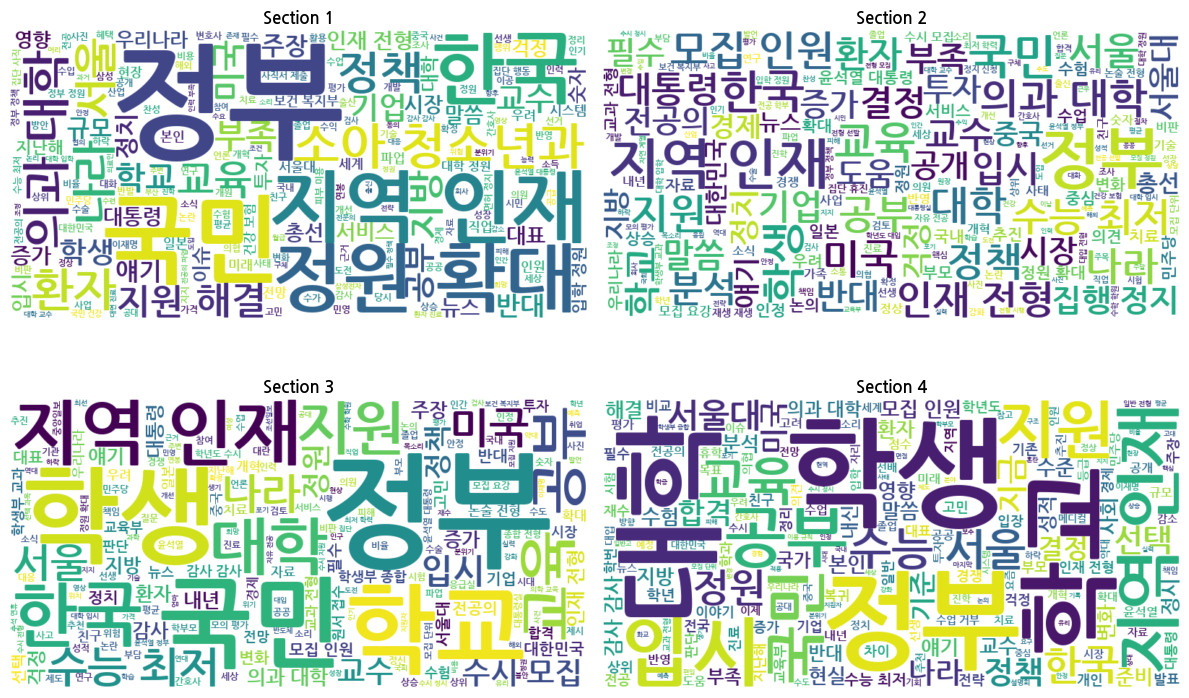

In [15]:
# =============================================================================
# WordCloud (4분기 2×2)
# =============================================================================
# [실행 시 나오는 것]
#   - 그림 창: 분기별로 자주 나온 단어가 크게 보임 (한글 폰트가 없으면 글자가 깨질 수 있음)
# [저장 파일] outputs/pipeline/wordcloud_by_section.png
# [주의] wordcloud 패키지가 없으면 메시지만 출력되고 그림은 생략
# =============================================================================

from wordcloud import WordCloud

if WordCloud:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for i, s in enumerate((1, 2, 3, 4)):
        ax = axes.ravel()[i]
        text = " ".join(w for row in df.loc[df["section"] == s, "nouns_final"] for w in row)
        wc = (
            WordCloud(_nanum_ttf, width=800, height=400, background_color="white").generate(text)
            if text.strip()
            else None
        )
        if wc:
            ax.imshow(wc, interpolation="bilinear")
        else:
            ax.text(0.5, 0.5, "(empty)", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Section {s}")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_WC / "wordcloud_by_section.png", dpi=150, bbox_inches="tight")
    plt.show()


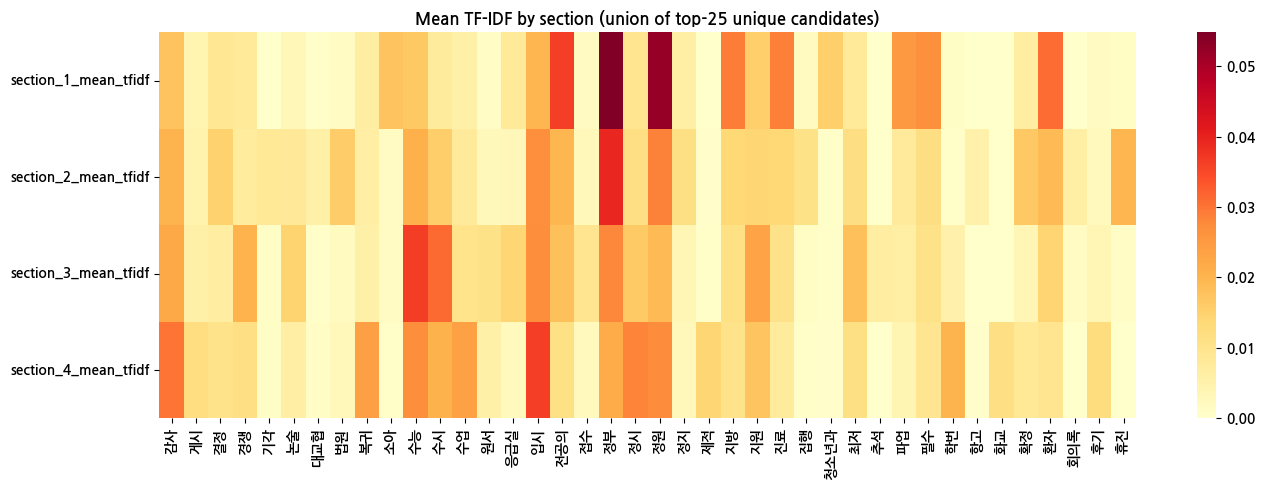

In [16]:
# =============================================================================
# TF-IDF 히트맵 (고유어 후보 union)
# =============================================================================
# [실행 시 나오는 것]
#   - 히트맵: 가로=단어, 세로=section_1~4 평균 TF-IDF 행. 색이 진할수록 그 분기에서 점수 높음
# [저장 파일] outputs/pipeline/tfidf_heatmap_union_top.png
# =============================================================================

union_terms = set()
for s in (1, 2, 3, 4):
    union_terms.update(scored.sort_values(f"diff_vs_others_max_s{s}", ascending=False).head(10).index)
union_terms = sorted(union_terms)
heat = wide_tfidf.reindex(union_terms).T
plt.figure(figsize=(max(10, len(union_terms) * 0.35), 5))
sns.heatmap(heat, cmap="YlOrRd", xticklabels=True)
plt.title("Mean TF-IDF by section (union of top-25 unique candidates)")
plt.tight_layout()
plt.savefig(OUT_DIR / "tfidf_heatmap_union_top.png", dpi=150, bbox_inches="tight")
plt.show()


#### 해석: 의대 증원 담론이 시간이 갈수록 “정책/의료 갈등”에서 “대입 전형/수험 전략”으로 이동했다

## Step 5 — layered pickle 저장


In [ ]:
# =============================================================================
# 최종 DataFrame 저장 (파생 열 포함)
# =============================================================================
# [실행 시 나오는 것]
#   - saved 와 파일 경로 한 줄: 저장 성공 여부 확인용
# [저장 파일] data/integrated/crolling_total_estate_press_layered.pkl
#       raw / clean / final 명사, corpus_*, nouns_final 등 분석에 쓴 열이 모두 들어 있음
#       용량이 클 수 있음 — 필요 없는 열은 나중에 drop 후 다시 저장 가능
# =============================================================================

with open(PKL_OUT, "wb") as f:
    pickle.dump(df, f, protocol=pickle.HIGHEST_PROTOCOL)
print("saved", PKL_OUT)


## Step 6 — 구간별 KMeans · LDA (`nouns_final` 기반)

**6a** 아래 셀에서 `analysis_df`를 준비합니다. **6b** KMeans, **6c** LDA를 순서대로 실행하세요.


### Step 6a — 데이터 준비

layered PKL 또는 Step 5 직후 메모리의 `df`에서 `doc_text_filtered`를 만듭니다.


In [17]:
# =============================================================================
# Step 6: layered PKL → KMeans / LDA (최종 명사 리스트 기준)
# =============================================================================
import pickle
from pathlib import Path

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from project_paths import (
    DATA_INTEGRATED,
    OUTPUTS_PIPELINE_KMEANS,
    OUTPUTS_PIPELINE_LDA,
)

KMEANS_DIR = OUTPUTS_PIPELINE_KMEANS
LDA_DIR = OUTPUTS_PIPELINE_LDA
for _p in (KMEANS_DIR, LDA_DIR):
    _p.mkdir(parents=True, exist_ok=True)

KMEANS_N_CLUSTERS = 3
LDA_N_TOPICS = 5
TOP_N_WORDS = 15
SECTION_NAME_MAP = {
    1: "1구간 (2024.01~03)",
    2: "2구간 (2024.04~06)",
    3: "3구간 (2024.07~12)",
    4: "4구간 (2025.01~06)",
}
SECTION_ORDER = [SECTION_NAME_MAP[i] for i in sorted(SECTION_NAME_MAP)]


def normalize_text(value):
    if isinstance(value, list):
        value = " ".join(map(str, value))
    if pd.isna(value):
        return ""
    return " ".join(str(value).split())


def save_csv_utf8(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")


def extract_top_terms(weights, feature_names, item_name, top_n=15):
    rows = []
    for item_id, item_weights in enumerate(weights):
        top_indices = item_weights.argsort()[::-1][:top_n]
        for rank, idx in enumerate(top_indices, start=1):
            rows.append(
                {
                    item_name: item_id,
                    "rank": rank,
                    "keyword": feature_names[idx],
                    "weight": float(item_weights[idx]),
                }
            )
    return pd.DataFrame(rows)


def build_section_ratio_table(df: pd.DataFrame, value_col: str):
    out = (
        df.groupby(["section", "section_name", value_col])
        .size()
        .rename("doc_count")
        .reset_index()
    )
    out["section_total"] = out.groupby("section")["doc_count"].transform("sum")
    out["ratio"] = out["doc_count"] / out["section_total"]
    return out


if "df" not in dir():
    df = None
if df is None or "nouns_final" not in df.columns:
    _pkl = DATA_INTEGRATED / "crolling_total_estate_press_layered.pkl"
    with open(_pkl, "rb") as f:
        df = pickle.load(f)
    print("loaded", _pkl)
else:
    print("using in-memory df from Step 5")

analysis_df = df.copy()
analysis_df["doc_text_filtered"] = analysis_df["nouns_final"].map(
    lambda xs: " ".join(str(w) for w in xs) if isinstance(xs, list) else normalize_text(xs)
)
for col in ["like", "comment_cnt"]:
    if col not in analysis_df.columns:
        analysis_df[col] = 0
analysis_df["doc_text_filtered"] = analysis_df["doc_text_filtered"].apply(normalize_text)
analysis_df["section"] = pd.to_numeric(analysis_df["section"], errors="coerce")
analysis_df["date"] = pd.to_datetime(analysis_df.get("date", pd.NaT), errors="coerce")
analysis_df["like"] = pd.to_numeric(analysis_df["like"], errors="coerce").fillna(0).astype(int)
analysis_df["comment_cnt"] = pd.to_numeric(analysis_df["comment_cnt"], errors="coerce").fillna(0).astype(int)
analysis_df = analysis_df[["title", "date", "section", "like", "comment_cnt", "doc_text_filtered"]].copy()
analysis_df = analysis_df.dropna(subset=["section", "doc_text_filtered"])
analysis_df = analysis_df[analysis_df["doc_text_filtered"].str.len() > 0].copy()
analysis_df["section"] = analysis_df["section"].astype(int)
analysis_df["section_name"] = analysis_df["section"].map(SECTION_NAME_MAP)
analysis_df["token_count"] = analysis_df["doc_text_filtered"].str.split().str.len()
analysis_df = analysis_df.sort_values(["section", "date", "title"]).reset_index(drop=True)
print("documents:", len(analysis_df))


using in-memory df from Step 5
documents: 8946


### Step 6b — KMeans


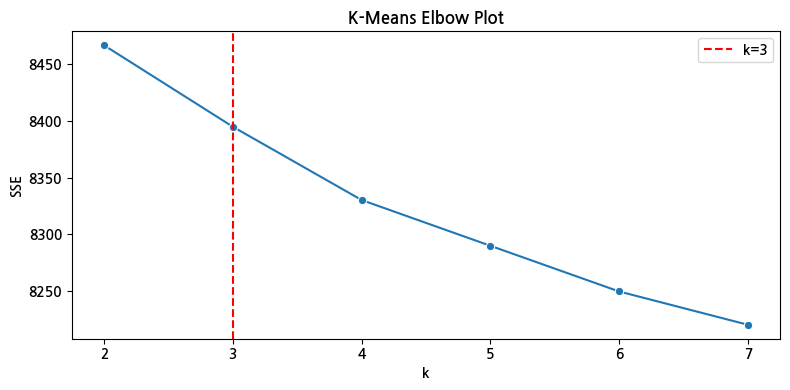

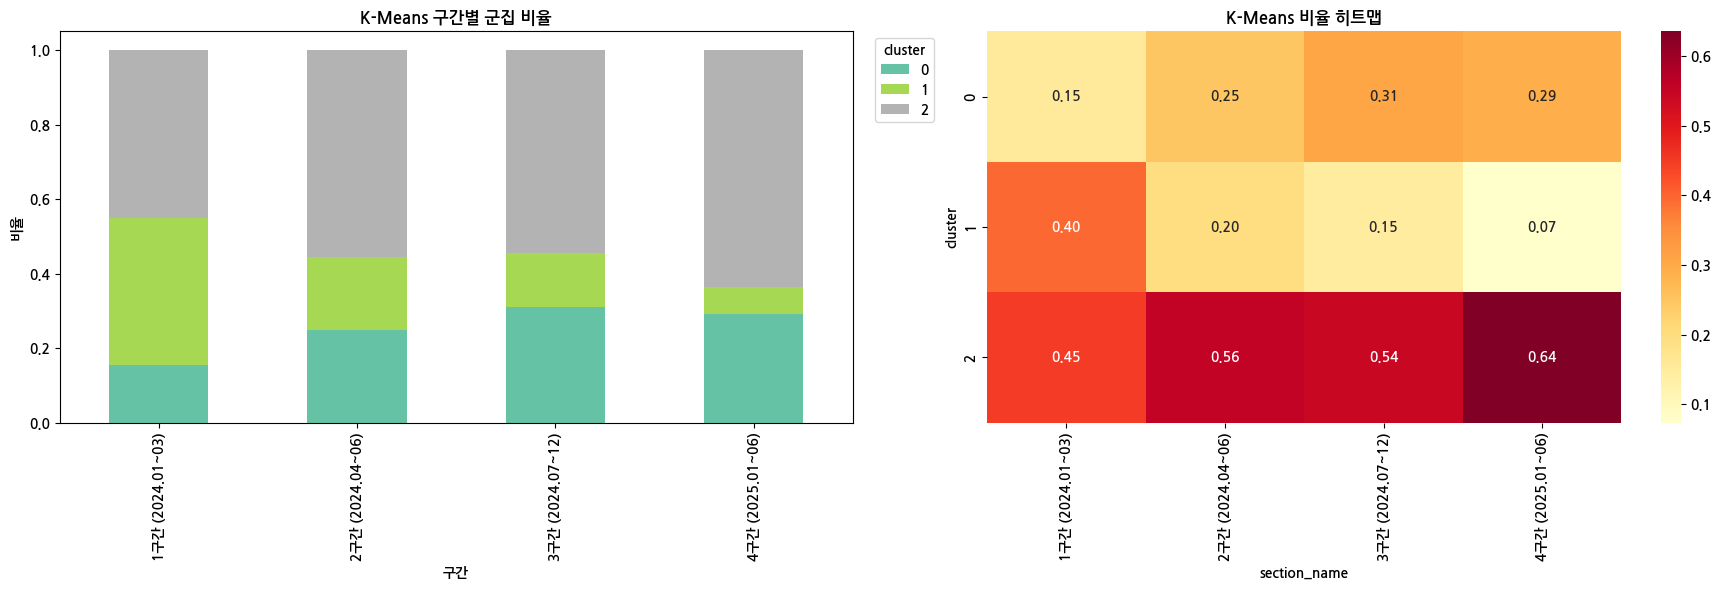

Step 6b (KMeans) done — outputs under kmeans/


In [18]:
# --- KMeans ---
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.85)
tfidf_matrix = tfidf_vectorizer.fit_transform(analysis_df["doc_text_filtered"])
elbow_rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(tfidf_matrix)
    elbow_rows.append({"k": k, "sse": km.inertia_})
kmeans_elbow_df = pd.DataFrame(elbow_rows)
save_csv_utf8(kmeans_elbow_df, KMEANS_DIR / "kmeans_elbow.csv")

plt.figure(figsize=(8, 4))
sns.lineplot(data=kmeans_elbow_df, x="k", y="sse", marker="o")
plt.axvline(KMEANS_N_CLUSTERS, color="red", linestyle="--", label=f"k={KMEANS_N_CLUSTERS}")
plt.title("K-Means Elbow Plot")
plt.xlabel("k")
plt.ylabel("SSE")
plt.legend()
plt.tight_layout()
plt.show()

kmeans_model = KMeans(n_clusters=KMEANS_N_CLUSTERS, n_init=20, random_state=42)
analysis_df["cluster"] = kmeans_model.fit_predict(tfidf_matrix)
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
kmeans_top_terms_df = extract_top_terms(
    weights=kmeans_model.cluster_centers_,
    feature_names=tfidf_feature_names,
    item_name="cluster",
    top_n=TOP_N_WORDS,
)
cluster_size_df = (
    analysis_df["cluster"].value_counts().sort_index().rename("cluster_size")
)
kmeans_top_terms_df = kmeans_top_terms_df.merge(
    cluster_size_df, left_on="cluster", right_index=True, how="left"
)
save_csv_utf8(kmeans_top_terms_df, KMEANS_DIR / "kmeans_cluster_top_terms.csv")

kmeans_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt", "cluster"]
].copy()
save_csv_utf8(kmeans_doc_df, KMEANS_DIR / "kmeans_doc_assignments.csv")

kmeans_section_distribution = build_section_ratio_table(kmeans_doc_df, value_col="cluster")
save_csv_utf8(kmeans_section_distribution, KMEANS_DIR / "kmeans_section_distribution.csv")

kmeans_pivot = kmeans_section_distribution.pivot(
    index="section_name", columns="cluster", values="ratio"
)
kmeans_pivot = kmeans_pivot.reindex(index=SECTION_ORDER).reindex(columns=range(KMEANS_N_CLUSTERS)).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
kmeans_pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("K-Means 구간별 군집 비율")
axes[0].set_xlabel("구간")
axes[0].set_ylabel("비율")
axes[0].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.heatmap(kmeans_pivot.T, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("K-Means 비율 히트맵")
plt.tight_layout()
plt.show()
print("Step 6b (KMeans) done — outputs under kmeans/")


### Step 6c — LDA


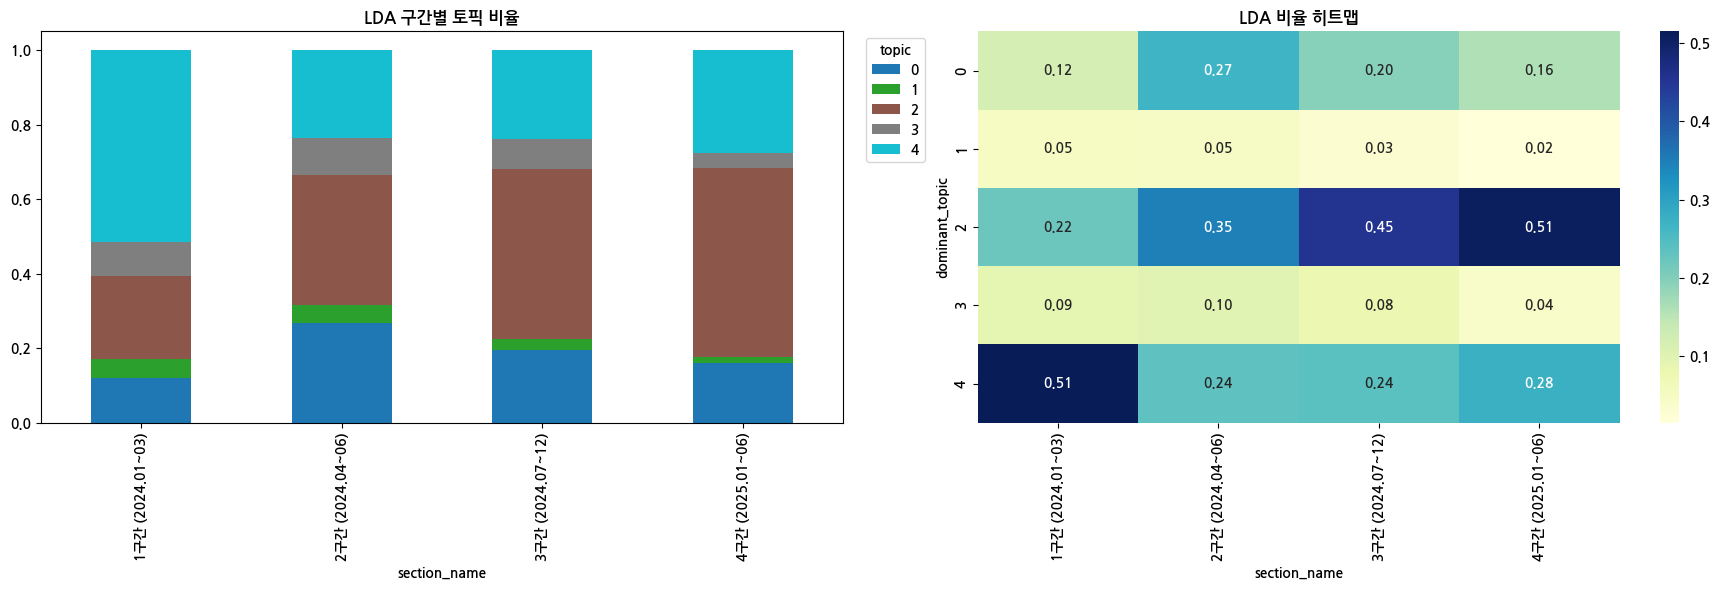

Step 6c (LDA) done — outputs under lda/


In [19]:
# --- LDA ---
count_vectorizer = CountVectorizer(min_df=5, max_df=0.85)
count_matrix = count_vectorizer.fit_transform(analysis_df["doc_text_filtered"])
lda_model = LatentDirichletAllocation(
    n_components=LDA_N_TOPICS, max_iter=30, learning_method="online", random_state=42, n_jobs=-1
)
lda_topics = lda_model.fit_transform(count_matrix)
analysis_df["dominant_topic"] = lda_topics.argmax(axis=1)
count_feature_names = np.array(count_vectorizer.get_feature_names_out())
lda_top_terms_df = extract_top_terms(
    weights=lda_model.components_,
    feature_names=count_feature_names,
    item_name="topic",
    top_n=TOP_N_WORDS,
)
save_csv_utf8(lda_top_terms_df, LDA_DIR / "lda_topic_top_terms.csv")

lda_doc_df = analysis_df[
    ["title", "date", "section", "section_name", "like", "comment_cnt", "dominant_topic"]
].copy()
save_csv_utf8(lda_doc_df, LDA_DIR / "lda_doc_assignments.csv")

lda_section_distribution = build_section_ratio_table(lda_doc_df, value_col="dominant_topic")
save_csv_utf8(lda_section_distribution, LDA_DIR / "lda_section_distribution.csv")

lda_pivot = lda_section_distribution.pivot(
    index="section_name", columns="dominant_topic", values="ratio"
)
lda_pivot = lda_pivot.reindex(index=SECTION_ORDER).reindex(columns=range(LDA_N_TOPICS)).fillna(0)
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))
lda_pivot.plot(kind="bar", stacked=True, ax=axes2[0], colormap="tab10")
axes2[0].set_title("LDA 구간별 토픽 비율")
axes2[0].legend(title="topic", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.heatmap(lda_pivot.T, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes2[1])
axes2[1].set_title("LDA 비율 히트맵")
plt.tight_layout()
plt.show()

print("Step 6c (LDA) done — outputs under lda/")


## Step 7 — 군집·토픽 해석과 반응 지표 정리

Step 6에서 생성한 K-Means 군집과 LDA 토픽 결과를 사람이 읽을 수 있는 담론 유형으로 정리하고, 좋아요·댓글 수를 이용해 각 담론의 반응 특성을 비교합니다.  
**전제:** Step 6b·6c까지 실행해 `kmeans_doc_df`, `lda_doc_df`, `kmeans_top_terms_df`, `lda_top_terms_df`, `analysis_df`가 준비된 상태에서 실행하세요.

- **Step 7a**: 군집·토픽별 상위 키워드 확인 및 해석용 라벨 지정
- **Step 7b**: 군집·토픽별 좋아요·댓글 분포 박스플롯
- **Step 7c**: 구간별 좋아요·댓글 분포 박스플롯
- **Step 7d**: K-Means, LDA, TF-IDF 결과를 종합해 해석 메모 작성


### Step 7a — 군집·토픽 해석 준비

이 단계에서는 상위 키워드를 바탕으로  
각 군집과 토픽에 사람이 읽을 수 있는 해석 라벨을 붙인다.

처음에는 기본 라벨(`Cluster 0`, `Topic 0`)로 두고,  
키워드를 확인한 뒤 아래 딕셔너리만 수정하면 된다.


In [20]:
# =========================================
# 군집 / 토픽 키워드 묶음 확인
# =========================================

cluster_keyword_summary = (
    kmeans_top_terms_df.sort_values(["cluster", "rank"])
    .groupby("cluster")["keyword"]
    .apply(list)
)

topic_keyword_summary = (
    lda_top_terms_df.sort_values(["topic", "rank"])
    .groupby("topic")["keyword"]
    .apply(list)
)

print("[K-Means 군집별 키워드]")
display(cluster_keyword_summary)

print("[LDA 토픽별 키워드]")
display(topic_keyword_summary)


[K-Means 군집별 키워드]


cluster
0    [전형, 수능, 입시, 수시, 대학, 지역, 모집, 인재, 등급, 학생, 정시, 학...
1    [정부, 전공의, 환자, 교수, 국민, 진료, 정원, 필수, 정책, 파업, 집단, ...
2    [정부, 정원, 대통령, 대학, 국민, 교육, 감사, 미국, 윤석열, 학생, 한국,...
Name: keyword, dtype: object

[LDA 토픽별 키워드]


topic
0    [정부, 대통령, 국민, 윤석열, 정치, 의원, 정원, 정책, 대표, 국회, 교수,...
1    [기업, 미국, 시장, 반도체, 상승, 기술, 사업, 투자, 국내, 산업, 주식, ...
2    [대학, 전형, 수능, 입시, 학생, 지역, 모집, 수시, 학년도, 지원, 인재, ...
3    [한국, 서울, 경제, 미국, 아파트, 뉴스, 금리, 중국, 일본, 가격, 시장, ...
4    [정부, 환자, 전공의, 정원, 진료, 교수, 필수, 국민, 정책, 대학, 지방, ...
Name: keyword, dtype: object

In [25]:
# =========================================
# 해석용 라벨 수동 지정
# =========================================

# 처음 실행할 때는 기본 라벨을 사용한다.
# 키워드를 본 뒤 아래 내용을 직접 수정하면 된다.

cluster_label_map = {
    0: "입시·대학 담론형",
    1: "의료현장 갈등형",
    2: "정책·정치/사회 파급형",
}

topic_label_map = {
    0: "정책·정치",
    1: "경제·투자",
    2: "입시·교육",
    3: "사회·경제",
    4: "의료현장",
}


kmeans_doc_df["cluster_label"] = kmeans_doc_df["cluster"].map(cluster_label_map)
lda_doc_df["topic_label"] = lda_doc_df["dominant_topic"].map(topic_label_map)

print("라벨 적용 완료")
display(kmeans_doc_df.head(3))
display(lda_doc_df.head(3))


라벨 적용 완료


,title,date,section,section_name,like,comment_cnt,cluster,cluster_label
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,1,의료현장 갈등형
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,2,정책·정치/사회 파급형
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,2024-01-01,1,1구간 (2024.01~03),14,4,2,정책·정치/사회 파급형


,title,date,section,section_name,like,comment_cnt,dominant_topic,topic_label
0,12월31일 아이가 어제 응급실 뺑뺑했어요,2024-01-01,1,1구간 (2024.01~03),2,146,4,의료현장
1,2024년신년사 서울아산병원장 청라 개원 관련 여러번 언급,2024-01-01,1,1구간 (2024.01~03),54,18,1,경제·투자
2,몇가지 이때까지의 뉴스들 생각정리 10억 순자산 20억자산가 미술품 투자수단 추세 ...,2024-01-01,1,1구간 (2024.01~03),14,4,1,경제·투자


### Step 7b — 반응 지표 시각화

계획서의 시각화 방향에 맞춰  
좋아요 수와 댓글 수의 분포를 박스플롯으로 확인한다.

- 군집별 좋아요 분포
- 군집별 댓글 수 분포
- 토픽별 좋아요 분포
- 토픽별 댓글 수 분포
- 구간별 좋아요 / 댓글 분포


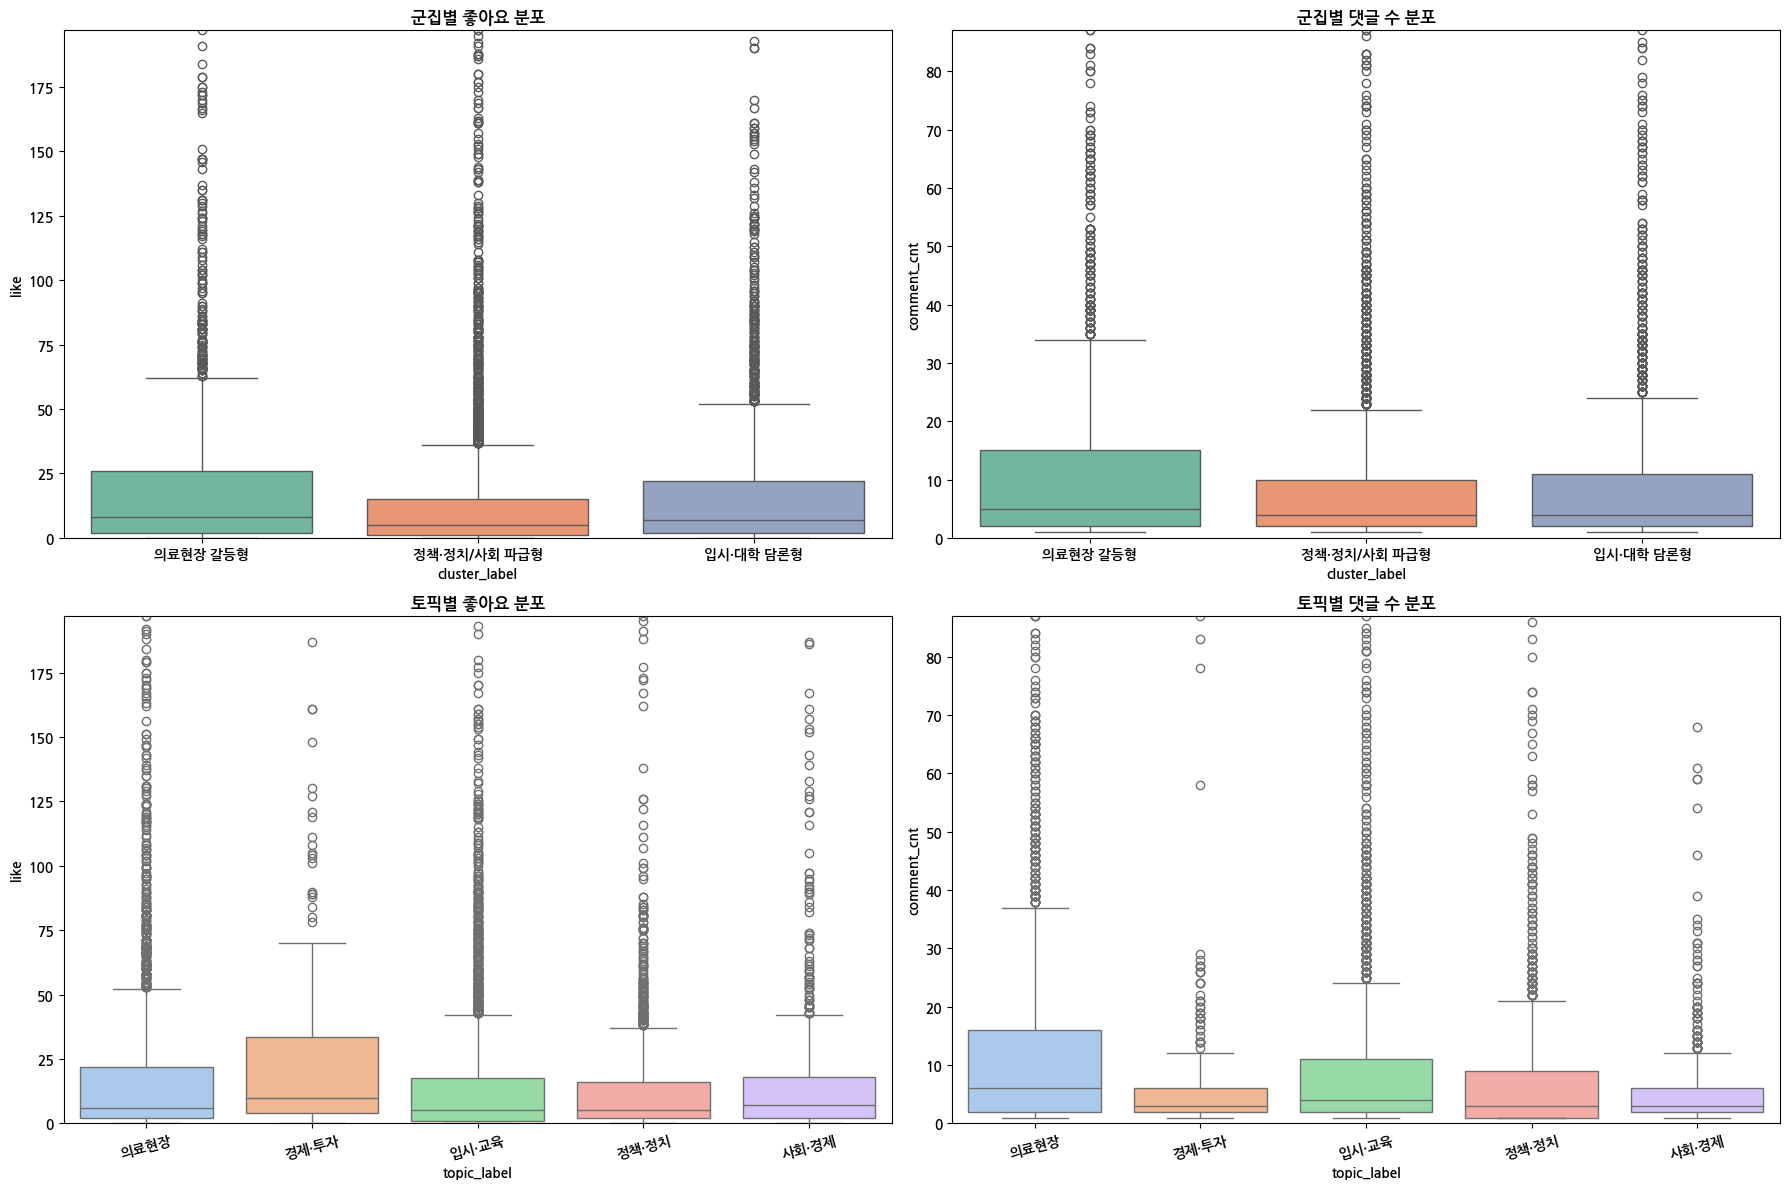

In [26]:
# =========================================
# 군집 / 토픽별 반응 지표 박스플롯
# =========================================

cluster_ylim_like = max(1, kmeans_doc_df["like"].quantile(0.99))
cluster_ylim_comment = max(1, kmeans_doc_df["comment_cnt"].quantile(0.99))

topic_ylim_like = max(1, lda_doc_df["like"].quantile(0.99))
topic_ylim_comment = max(1, lda_doc_df["comment_cnt"].quantile(0.99))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(
    data=kmeans_doc_df,
    x="cluster_label",
    y="like",
    hue="cluster_label",
    ax=axes[0, 0],
    palette="Set2",
    legend=False,
)
axes[0, 0].set_title("군집별 좋아요 분포")
axes[0, 0].set_ylim(0, cluster_ylim_like)

sns.boxplot(
    data=kmeans_doc_df,
    x="cluster_label",
    y="comment_cnt",
    hue="cluster_label",
    ax=axes[0, 1],
    palette="Set2",
    legend=False,
)
axes[0, 1].set_title("군집별 댓글 수 분포")
axes[0, 1].set_ylim(0, cluster_ylim_comment)

sns.boxplot(
    data=lda_doc_df,
    x="topic_label",
    y="like",
    hue="topic_label",
    ax=axes[1, 0],
    palette="pastel",
    legend=False,
)
axes[1, 0].set_title("토픽별 좋아요 분포")
axes[1, 0].set_ylim(0, topic_ylim_like)
axes[1, 0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=lda_doc_df,
    x="topic_label",
    y="comment_cnt",
    hue="topic_label",
    ax=axes[1, 1],
    palette="pastel",
    legend=False,
)
axes[1, 1].set_title("토픽별 댓글 수 분포")
axes[1, 1].set_ylim(0, topic_ylim_comment)
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(OUTPUTS_PIPELINE_KMEANS / "boxplot_section_like_comment.png", dpi=150, bbox_inches="tight")
plt.show()


### Step 7c — 구간별 반응 지표 시각화

이번 셀은 군집·토픽 구분과 별도로, 1~4구간 자체의 좋아요 수와 댓글 수 분포를 비교합니다.  
이를 통해 특정 시기에 전반적인 공감 반응이나 논쟁 참여가 커졌는지 확인할 수 있습니다.

**해석 작성 칸**  
- 좋아요 분포가 가장 높거나 넓게 퍼진 구간:
- 댓글 수 분포가 가장 높거나 넓게 퍼진 구간:
- 구간별 반응 차이가 담론 변화와 연결되는 지점:


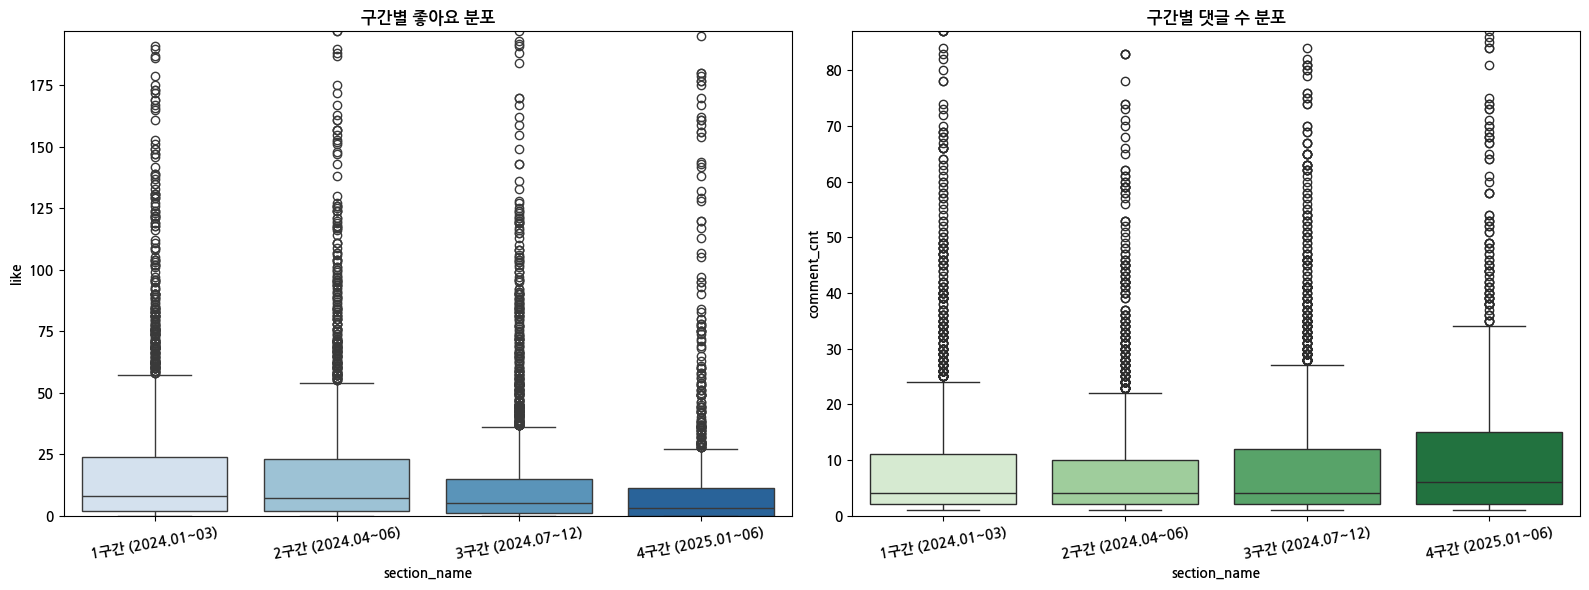

In [23]:
# =========================================
# 구간별 반응 지표 박스플롯
# =========================================

section_ylim_like = max(1, analysis_df["like"].quantile(0.99))
section_ylim_comment = max(1, analysis_df["comment_cnt"].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=analysis_df,
    x="section_name",
    y="like",
    order=SECTION_ORDER,
    hue="section_name",
    hue_order=SECTION_ORDER,
    ax=axes[0],
    palette="Blues",
    legend=False,
)
axes[0].set_title("구간별 좋아요 분포")
axes[0].set_ylim(0, section_ylim_like)
axes[0].tick_params(axis="x", rotation=10)

sns.boxplot(
    data=analysis_df,
    x="section_name",
    y="comment_cnt",
    order=SECTION_ORDER,
    hue="section_name",
    hue_order=SECTION_ORDER,
    ax=axes[1],
    palette="Greens",
    legend=False,
)
axes[1].set_title("구간별 댓글 수 분포")
axes[1].set_ylim(0, section_ylim_comment)
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()


### 1. 구간별 핵심 키워드 변화
- 1구간: `정부·정원·전공의·환자·진료`가 두드러져, 정책 발표 직후의 의료현장 갈등과 공공성 논의가 중심이었다.
- 2구간: `정부·대학·전형·정원·학생`이 함께 나타나, 정책 이슈가 대학·입시 담론과 본격적으로 연결되기 시작했다.
- 3구간: `대학·전형·수능·학생·지원·감사`가 부각돼, 의료 갈등보다 입시·선발 구조와 제도 점검 이슈가 더 강해졌다.
- 4구간: `대학·감사·전형·학생·입시·수능`이 핵심으로 나타나, 담론의 무게중심이 입시·대학 제도 쪽으로 이동한 모습이다.

### 2. K-Means 군집 해석
- 군집 0: `전형·수능·입시·수시·대학` 중심의 `입시·대학 담론형`
- 군집 1: `정부·전공의·환자·교수·진료` 중심의 `의료현장 갈등형`
- 군집 2: `정부·정원·대통령·교육` 중심의 `정책·정치/사회 파급형`
- 구간별 군집 비율 변화: 군집 1은 `39.5% → 7.3%`로 크게 감소했고, 군집 0은 `15.4% → 30% 내외`로 확대됐다. 군집 2는 전 구간에서 가장 큰 비중을 차지하며 `45.1% → 63.6%`로 더 강해졌다.

### 3. LDA 토픽 해석
- Topic 0: `정부·대통령·국민·윤석열·정치` 중심의 `정책·정치 토픽`
- Topic 1: `기업·미국·시장·반도체·상승` 중심의 `경제·투자 파생 토픽`
- Topic 2: `대학·전형·수능·입시·학생` 중심의 `입시·교육 토픽`
- Topic 3: `한국·서울·경제·아파트·금리` 중심의 `사회·경제 일반 토픽`
- Topic 4: `정부·환자·전공의·정원·진료` 중심의 `의료현장·의정갈등 토픽`
- 구간별 토픽 비율 변화: Topic 4는 1구간 `51.4%`로 가장 강했지만 이후 약화됐고, Topic 2는 `22.2% → 50.7%`로 꾸준히 확대됐다. Topic 0은 2구간 `26.8%`로 일시적으로 강화돼 정책·정치 논쟁이 중간 시기에 부각됐다.

### 4. 반응 지표 해석
- 좋아요 수가 두드러진 군집·토픽: 군집 기준으로는 `군집 1`이 가장 높았다. 토픽 기준으로는 `Topic 1`의 평균 좋아요가 높지만 비중이 작고, 핵심 이슈 토픽 중에서는 `Topic 4`의 반응이 가장 강했다.
- 댓글 수가 두드러진 군집·토픽: `군집 1`과 `Topic 4`가 가장 높아, 의료현장 갈등 담론이 가장 많은 토론과 참여를 유발했다.
- 시기별 반응 강도의 변화: 좋아요는 1구간이 가장 높고 후반으로 갈수록 약해졌으며, 댓글은 4구간에서 다시 강해져 후반부에는 `공감`보다 `논쟁·참여` 반응이 더 두드러졌다.

### 5. 종합 결론
- 온라인 여론의 전반적 변화: 초기에는 `정책 발표와 의료현장 충돌`이 중심이었고, 시간이 지나면서 `대학·전형·수능·입시` 중심의 제도적·실질적 영향 논의로 무게중심이 이동했다.
- 분석의 한계: 네이버 블로그·카페 자료만 사용해 전체 여론을 대표하기 어렵고, 형태소 분석·불용어 처리 방식에 따라 결과가 달라질 수 있다. 또한 LDA 일부 토픽은 경제·사회 일반 이슈가 섞여 있어 순수한 의대 증원 담론만 분리되지는 않았다.